# Assignment 4: Regularization

In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

The intuition of adding a penalty to mean squared error that grows in the size of the model parameters is to attempt to reduce the efficiency of overly complex models to prevent overfitting. The model attempting to create the lowest possible error could possibly use many complex variables to lower the error as much as possible, but this ends up in a model that is highly sensitive to noise and is not very generalizable. By introducing this penalty, you make the model balance having a model that is a good "fit" and a model that is simple, which may lead to more error in the training set but will ultimately be more generalizable to other data. This way, the model will focus on the key trends and patterns that have a significant impact on the data rather than attempting to focus on every possible bit of noise that might help it "game" the error.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization provides a way to explore the bias-variance trade-off by introducing a penalty parameter that represents just how much error or punishment we are putting onto the model. The balance between bias and variance is directly represented in the balance bewteen minimizing the error and keeping the model simple in this context. For example, an alpha value that is low may allow a model that has a leaning towards maximizing accuracy while assuming high variance, while a regularization model that has a very high alpha value correlating to punishment may favor a model that has less accuracy but lower variance, improving generalizibility. Ultimately, regularization through manipulation of the punishment values and the parameters is a direct exploration of this trade-off.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Though LASSO and Ridge regression are both based on the concept of adding a "penalty" to the model for overcomplexity, they have different mechanisms of function. Firstly, the method of calculation is different. LASSO takes absolute values while Ridge will take squared values. This math is different. Secondly, LASSO has the capability to push coefficents to exactly 0 rapidly, isolating variables and creating more sudden changes to improve the model's predicting power. This makes a simpler and more interpretable model quickly while choosing a model specifiction for you, but can make it susceptible to small changes in data as the model can swing in structure fast. On the other hand, Ridge gradually shrinks the effect of coefficents but does not have the same zeroing power that LASSO does, making the changes to the model more gradual as the data changes. This is naturally more stable, producing smoother coefficient estimate values for smaller changes in data. This results in Ridge having better predictive power overall in terms of reliability, while LASSO gives a more interpretable model sooner as it drops variables entirely if it maximizes the result, isolating what is the truly impactful trends.

4. How do we typically scale variables for use in regularized regression? Why?

We typically scale numeric variables with a z-score standardization to better fit with the math of the penalty and to prevent regularization from altering coefficients inappropriately due to scale rather than actual prediction. Since coefficient values are considered in the model here, the scale of the data values matter because data values with vastly different scales and what an incremental increase or decrease means will skew the model's predictive power since fundamentally, the scales are not standardized among different variables. This means that the size of the coefficient may not always accurately reflect the true impact of the feature since the model is trying to balance arbitrary units rather than performance. A change in one unit does not mean the same thing across vastly different units, making numeric variables not always easily comparable. A standardization will put things on a normalized, standard deviation scale, meaning the model can now directly compare coefficients to each other more validly and adjust the strength that way. Ultimately, it is important to ensure that the penalty is being applied fairly across each coefficient to prevent mismatched copmarisons, or for lack of a better term, trying to compare apples and oranges that exist on different scales.

5. How is the penalty $\alpha$ typically selected?

With reference to the lecture notes, the predictive alpha value is crucial as it determines, in simple terms, the penalty and how much it is going to weigh in the model. An alpha value too low will not be able to cause a meaningful change from an ordinary linear regression while an alpha value too high will push coefficents to zero excessively since coefficients will not be able to provide predictive power to justify the cost of the penalty in this situation. A middle area is considered a sweet spot and this is chosen by cross validaiton. Essentially, we pick a grid of alpha values, use a k-fCV for each value (picking the coefficients to minimize MSE(b-hat) + alpha|b-hat| or MSE(b-hat) + alpha(b-hat)^2 and then evaluating MSE(b-hat) on test folds and saving this estimate value), pick a mean or median value of this alpha value  for that MSE(b-hat), and then we compare these values across the grid andchoose an alpha value that gives the best trade-off bewteen bias and variance. Interestingly, this also gives a path of the coefficients as the alpha value changes.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

We do not include the penalty term in evaluating the cross validated MSE. Ultimately, the isolated MSE is the predictive power of the model, and the alpha value and penalties are only used in the training / model building phase to guide coefficient allocation. The penalty is an artificial change we are making on the model building phase to drive change but this will actually "bias" or skew our estimations if we try to include this in the final predictive evaluation. Some models might falsely look better than others in cross validation simply because of the size of the coefficients if this penalty is included, which means we may end up choosing alpha values and models that are actuall worse at raw predictive strength because we are trying to take coefficient size into consideration. This also defeats the purpose of cross validation, which is to compare true predictive power, not account for an artificial penalty value used in model creation.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.

Done.

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

The sign is negative.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

Done.

4. Plot the cross-validated MSE by $\alpha$.

Done.

5. Plot the coefficient paths by $\alpha$.

Done.

6. Which features are actually selected? What proportion are set equal to zero?

Looking at the plot, it looks like Mileage_Run and Age respectively got selected at the most optimal point by a relatively decent margin compared to the other polynomial generated factors. Due to the polynomial nature of the model, some other factors such as Age^3, Mileage_Run Age, and even Mileage_Run^3 look like it was incorporated at the optimal alpha value given the hint constraints. Some features, such as Mileage_Run^2 Age, Mileage_Run^2, Mileage_Run Age^2, and Age^2 looks to have been set equal to zero looking at the plot. The proportion set to zero is 5/9 (0.56 ish).

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Well, for starters, at the optimal LASSO, some of them just get set to equal zero as mentioned above. Coefficients such as Mileage_Run^2 Age, Mileage_Run^2, Mileage_Run Age^2, and Age^2 get set to zero at optimal levels. Mileage Run^2 Age was positive, Mileage Run^2 was negative, Mileage_Run Age^2 was positive, and Age^2 was positive. Mileage_Run ended up decreasing in magnitude but did not change sign. Age is hard to tell but it looks similar or the optimal regularized coefficient version may be more negative and did not change sign. Age^3 had a significant differnce and flipped signs from negative to positive outright and also decreased in absolute magnitude as it became a positive number. Mileage_Run Age had a substancial difference in magnitude as it shrank but did not change sign. Mileage_Run^3 looks similar to me as it was a relatively small magnitude negative number and this looks to be about the case in the optimal regularized version.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars = pd.read_csv("/content/data/cars_hw.csv")

year = 2026
cars["Age"] = year - cars["Make_Year"]

X = cars[["Mileage_Run", "Age"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

print(X_scaled)

[[ 0.12469203 -0.01309242 -0.13767332 ... -0.23076715 -0.19558597
  -0.27042227]
 [-0.87233418  0.34185769 -0.79131562 ... -0.71818608 -0.56489035
   0.04408937]
 [-0.49351672 -0.72299265 -0.60062321 ... -0.64800377 -0.70091085
  -0.71839826]
 ...
 [ 0.46248973  1.05175792  0.19479598 ...  0.32073381  0.73673979
   0.88897673]
 [-0.54294553 -1.07794277 -0.62951357 ... -0.69364241 -0.80062127
  -0.86578933]
 [-0.01621083 -0.36804254 -0.25974731 ... -0.38445401 -0.42380175
  -0.52226369]]


In [46]:
from sklearn.linear_model import LinearRegression
y = cars["Price"]

X = pd.DataFrame(X_scaled, columns=poly_names)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 741019.4672131148


,variable,coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


Optimal cost hyperparameter: 1000.0


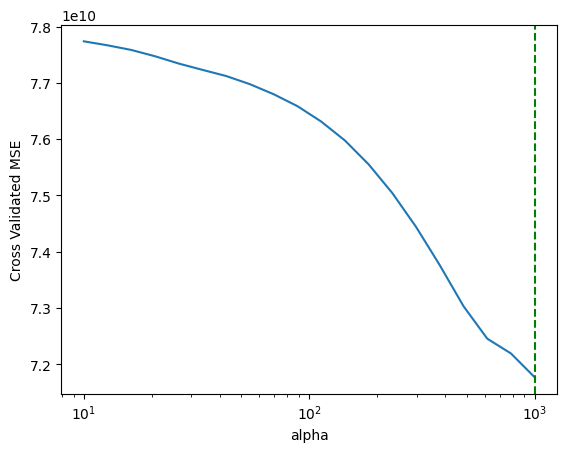

In [47]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.linear_model import LassoCV, lasso_path, Lasso

alpha_grid = np.logspace(1, 3, 20)
model = LassoCV(cv=20,
                alphas=alpha_grid,max_iter = 10_000, random_state=100)
model = model.fit(X_scaled, y)
index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]
sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

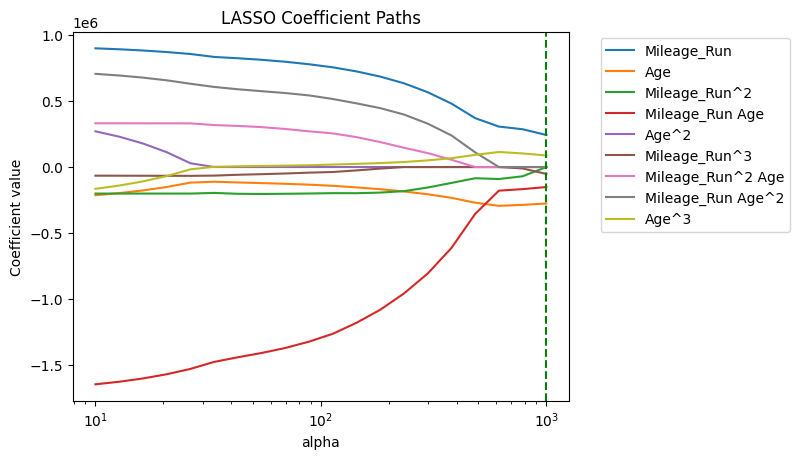

In [48]:
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X_scaled,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
var_names = poly_names
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

Done.

2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

In terms of sign patterns that appear counterintuitive, based on my table, I spot a few that raises some questions. Serum creatine is an interesting one. Though creatine itself can relate to muscle mass, thus indicating good health, depending on the population sampled this might not be the best medical assessment. Very high levels of creatine could indicate that there is a problem with kidney function and therefore also with circulation/filteirng blood. So a negative correlation here might be debateable since high serum creatine may indicate poor filteration or circulation. More than that, the negative sign of diabetes, high blood pressure, and smoking is very surprising as you would expect the opposite in a medical context. These factors usually lead to premature death and increase risk of heart complications. Therefore, some of the signs of these coefficients are surprising, and if they existed in a vaccuum many would say it is questionable at best and inaccurate at worst.

I can see how the inclusion of higher-order powers or interactions resolve contradictions. It is important to consider that the model is trying to capture higher order effects to maximize the best performance, so this singular coefficient's interaction may be accurate in the context of other compensating and complimentary non-linear relationships. If medical relationships are better represented in a non-linear way, than the model would prioritze the weighing of higher-order relationships over less-accurate isolated relationships. It is pretty hard to judge the higher order non-linear effects in a medical context, but yes, contradictions could make sense in the context of how the model is able to craft these relationships in a way that makes the most sense. For example, diabetes and smoking has a positive sign, which is expected for both and furthermore shows that there could be a significant non-linear interaction going on here in relation to the dependent variable of interest that is deeper than these factors isolated. This is intuitive, cause in many cases, these factors that are "bad" for your health will combine and amplify each other's effects. A balancing so to speak between not just itself but with other variables will offset the possible intuitive accuracy decrease by just creatine alone, demonstrating how models handle predictors that are commonly correlated and have combinatory effects. Also, it is interesting to note that the counterintuitive values for the categorical variables are pretty small and may exist solely to balance the model better in some cases.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

Done.

4. Plot the cross-validated MSE by $\alpha$.

Done.

5. Plot the coefficient paths by $\alpha$.

Done.

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In terms of the features actaully selected, given the pretty large number of total features, the answer is not much at least from the diagram made here. Only a handful of features are actually present at the optimal value, and these features seem to be ejection_fraction, serum_creatine, age^3, ejection_fraction^3, ejection_fraction^2 serum_creatine, high_blood_pressure, diabetes high_blood_pressure. The rest (about 20 ish) looks to be set to zero, and therefore, had the corresponding change in sign and magnitude. ejection_fraction did not change sign but shrank by a significant magnitude. serum_creatine flipped signs but the absolute change in magnitude was modest. age^3 did not flip signs but had a significant decrease in magnitude. ejection_fraction^3 flipped signs and had a decrease in absolute magnitude. ejection_fraction^2 and serum_creatine similarly had a change in sign in the same way and also had a significant decrease in absolute magnitude. For high_blood_pressure the change in magnitude was relatively small but there was a sign flip. diabetes high_blood_pressure maintained the same sign but had a decrease in magnitude. The proportion set to zero is 22/29 (0.76 ish). Firstly, since LASSO sets some features to zero, it is far more interpretable and it is easier to see which features may be the most important in prediction. I think at a glance the sign patterns in the LASSO makes more sense. It has trends that I would expect from a medical standpoint that is more logically sound in isolation than the linear regression. For example, blood pressure being high this time is actually positive and so is the effects of serum_creatine broadly. I think intuitively this can make sense because the linear regression has the ability to build a very complicated model to try to get the lowest error, so it might use some variables to optimize what can be considered noise in the data rather than give us real physiological trends. With that considered, the sign patterns for LASSO broadly makes more sense. This is the case if one thinks about the bias-variance trade off. Linear regression can hold a very high variance in exchange for low bias, and this allows the linear regression model to more aggressively manipulate its variables around to accomodate noise rather than logic or real trends. This causes some coefficient signs to look very counterintuitive. LASSO on the other hand is willing to accept a little more error in exchange for lower variance, so it is balancing this trade off more effectively to get more interpretable trends that are meaningful. This makes LASSO more resilient to noise as it intentionally tries to lower its own variance and complexity. From a bias-variance perspective, both models balance and prioritize differently, and LASSO, which is willing to accept higher error in exchange for lower variance, ultimately was able to generate more intuitive looking data and coefficient values.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

heart= pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")

numnames = ["age", "ejection_fraction", "serum_creatinine"]
X_num = heart[numnames]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_polyh = poly.fit_transform(X_num)
poly_namesh = poly.get_feature_names_out(numnames)

scaler = StandardScaler()
X_scaledh = scaler.fit_transform(X_polyh)

dumnames = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
Xdummy = heart[dumnames]

polydum = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
Xpolydh = polydum.fit_transform(Xdummy)
poly_namesdh = polydum.get_feature_names_out(dumnames)

Xfinalh = np.hstack([X_scaledh, Xpolydh])
feature = list(poly_namesh) + list(poly_namesdh)

print("Feature matrix shape:", Xfinalh.shape)
print("First 10 feature names:", feature[:29])

Feature matrix shape: (299, 29)
First 10 feature names: ['age', 'ejection_fraction', 'serum_creatinine', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^3', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction serum_creatinine^2', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']


In [61]:
from sklearn.linear_model import LinearRegression
y = heart["DEATH_EVENT"]

X = pd.DataFrame(Xfinalh, columns=feature)

model = LinearRegression()
model = model.fit(X, y)

print(f"Model intercept: {model.intercept_}")
pd.DataFrame({"variable":model.feature_names_in_, "coefficient":model.coef_ })

Model intercept: 0.3303641029499512


,variable,coefficient
0,age,1.539156
1,ejection_fraction,-2.192494
2,serum_creatinine,-0.853588
3,age^2,-3.678654
4,age ejection_fraction,-0.600918
5,age serum_creatinine,1.841563
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
9,age^3,1.993135


Optimal cost hyperparameter: 0.012689610031679234


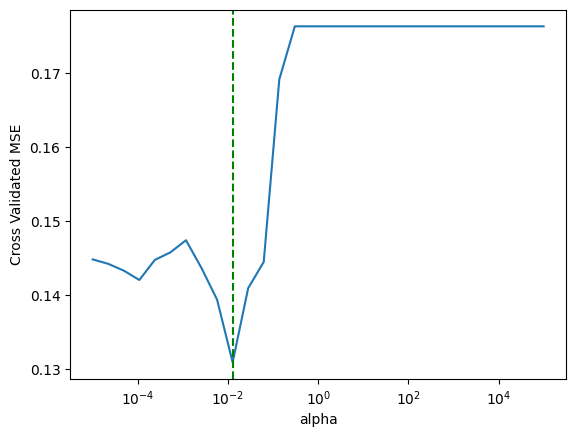

In [68]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.linear_model import LassoCV, lasso_path, Lasso

alphas = np.logspace(-5,5,30)
model = LassoCV(cv=20,
                alphas=alphas,max_iter = 10_000, random_state=100)
model = model.fit(X, y)
index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]
sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

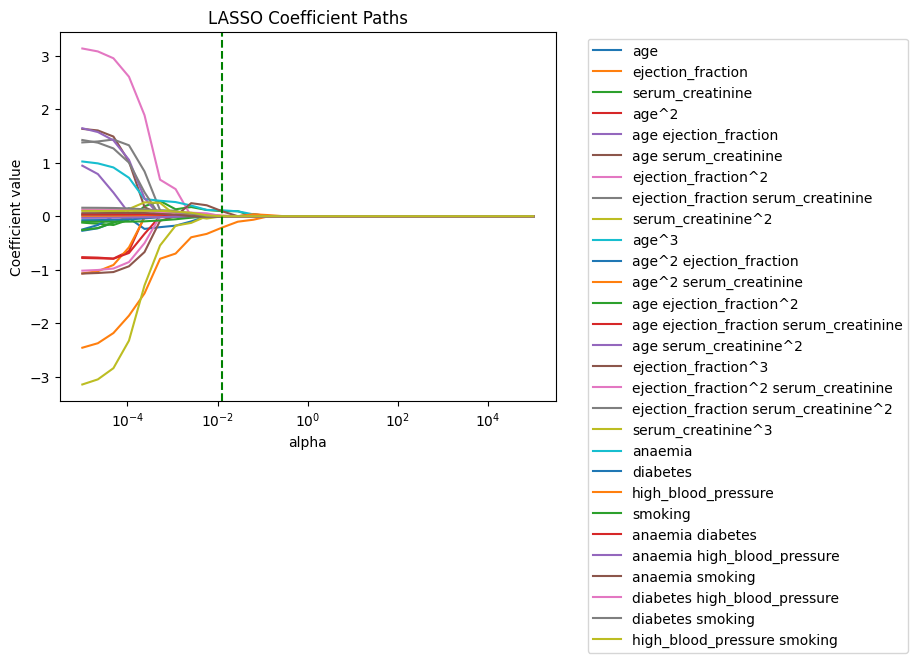

In [83]:
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
var_names = poly_names
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature [i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


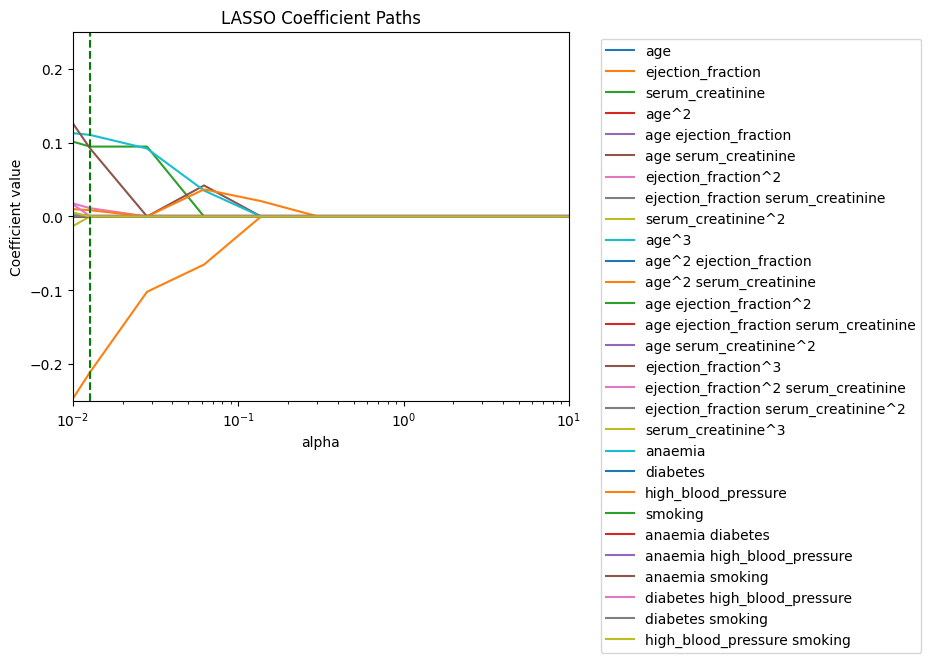

                                   Feature  Coefficient
0                                      age     0.000000
1                        ejection_fraction    -0.210622
2                         serum_creatinine     0.094559
3                                    age^2     0.000000
4                    age ejection_fraction    -0.000000
5                     age serum_creatinine     0.000000
6                      ejection_fraction^2     0.000000
7       ejection_fraction serum_creatinine     0.000000
8                       serum_creatinine^2    -0.000000
9                                    age^3     0.110404
10                 age^2 ejection_fraction     0.000000
11                  age^2 serum_creatinine     0.000000
12                 age ejection_fraction^2     0.000000
13  age ejection_fraction serum_creatinine     0.000000
14                  age serum_creatinine^2    -0.000000
15                     ejection_fraction^3     0.092220
16    ejection_fraction^2 serum_creatinine     0

In [86]:
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
var_names = poly_names
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature [i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlim(1e-2, 1e1)
plt.ylim(-0.25, 0.25)
plt.show()

idx = (np.abs(alphas - alpha_star)).argmin()
coefop = coefs[idx]
coefread = pd.DataFrame({
    'Feature': feature,
    'Coefficient': coefop
})
print(coefread)

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Image in the same repository